# Taller Deep Learning

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import yfinance as yf

from sklearn.preprocessing import StandardScaler#, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_absolute_error

warnings.simplefilter(action="ignore", category=FutureWarning)

np.random.seed(42)

## 1. Lectura y preprocesado de datos

Leemos los datos de los precios de cierre de las 23 acciones desde 1945. Vemos que solo hay datos desde 1962, así que tendremos datos desde ese mismo año.

In [ ]:
# Leemos los datos de los precios de cierre de las acciones desde 1945 hasta la fecha actual
#start_date = '1945-01-01'
#tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']
#precios_close = yf.download(tickers_validos, start=start_date, auto_adjust=True, progress=True)['Close']
#precios_close.head()

[*********************100%***********************]  23 of 23 completed


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,0.894096,0.190931,0.462332,0.284116,0.307970,0.057055,0.386574,0.240809,0.168170,0.617245,...,0.830128,0.060341,0.044744,0.031859,0.554942,0.002384,0.063742,0.613480,0.244460,0.088754
1962-01-03,0.892468,0.194749,0.466836,0.281340,0.307275,0.057821,0.383392,0.240809,0.173799,0.611052,...,0.818794,0.059403,0.043747,0.032528,0.559115,0.002341,0.061072,0.611697,0.241788,0.090072
1962-01-04,0.879439,0.192840,0.478844,0.281340,0.304494,0.057821,0.380211,0.240066,0.174503,0.603827,...,0.815961,0.058778,0.044080,0.032394,0.559115,0.002357,0.060449,0.606347,0.237781,0.090291
1962-01-05,0.859896,0.189022,0.483348,0.274553,0.296847,0.058012,0.372256,0.234863,0.175207,0.588343,...,0.824461,0.057840,0.043083,0.031591,0.544511,0.002384,0.058401,0.602781,0.236111,0.088314
1962-01-08,0.853381,0.189499,0.486350,0.271468,0.295456,0.057821,0.373051,0.235978,0.178021,0.587311,...,0.807461,0.056902,0.042640,0.031457,0.541381,0.002368,0.058579,0.592079,0.229766,0.088095


In [2]:
precios_close = pd.read_csv('precios_activos.csv', header=0, index_col=0)
precios_close.index = pd.to_datetime(precios_close.index, errors='coerce')
precios_close.head()

,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,0.894096,0.190931,0.462333,0.284116,0.307970,0.057055,0.386574,0.240809,0.168170,0.617244,...,0.830127,0.060341,0.044744,0.031859,0.554942,0.002384,0.063742,0.613480,0.244460,0.088754
1962-01-03,0.892467,0.194750,0.466836,0.281340,0.307275,0.057821,0.383392,0.240809,0.173799,0.611051,...,0.818794,0.059403,0.043747,0.032528,0.559115,0.002341,0.061072,0.611697,0.241788,0.090072
1962-01-04,0.879439,0.192840,0.478844,0.281340,0.304494,0.057821,0.380211,0.240066,0.174503,0.603827,...,0.815961,0.058778,0.044080,0.032394,0.559115,0.002357,0.060449,0.606346,0.237781,0.090291
1962-01-05,0.859895,0.189022,0.483347,0.274553,0.296847,0.058012,0.372257,0.234863,0.175207,0.588344,...,0.824460,0.057840,0.043083,0.031591,0.544511,0.002384,0.058401,0.602780,0.236111,0.088314
1962-01-08,0.853381,0.189499,0.486350,0.271468,0.295457,0.057821,0.373052,0.235978,0.178021,0.587312,...,0.807462,0.056902,0.042640,0.031457,0.541382,0.002368,0.058579,0.592080,0.229766,0.088095


Observamos que no hay problemas de valores nulos

In [3]:
precios_close.isna().sum()

AEP    0
BA     0
CAT    0
CNP    0
CVX    0
DIS    0
DTE    0
ED     0
GD     0
GE     0
HON    0
HPQ    0
IBM    0
IP     0
JNJ    0
KO     0
KR     0
MMM    0
MO     0
MRK    0
MSI    0
PG     0
XOM    0
dtype: int64

Finalmente calculamos los retornos de las acciones durante todo el periodo.

In [3]:
# Calculamos los retornos logarítmicos de los precios de cierre
returns = np.log(precios_close).diff().dropna()
returns.head()

,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001823,0.019803,0.009693,-0.009819,-0.002260,0.013333,-0.008265,0.000000,0.032925,-0.010084,...,-0.013746,-0.015671,-0.022531,0.020790,0.007491,-0.018518,-0.042803,-0.002911,-0.010989,0.014742
1962-01-04,-0.014705,-0.009852,0.025398,0.000000,-0.009090,0.000000,-0.008333,-0.003091,0.004040,-0.011894,...,-0.003466,-0.010578,0.007569,-0.004123,0.000000,0.006985,-0.010256,-0.008785,-0.016714,0.002436
1962-01-05,-0.022473,-0.020001,0.009360,-0.024419,-0.025436,0.003308,-0.021142,-0.021910,0.004025,-0.025975,...,0.010362,-0.016090,-0.022875,-0.025107,-0.026467,0.011534,-0.034462,-0.005899,-0.007047,-0.022141
1962-01-08,-0.007605,0.002522,0.006192,-0.011300,-0.004694,-0.003308,0.002134,0.004736,0.015936,-0.001756,...,-0.020833,-0.016348,-0.010335,-0.004245,-0.005763,-0.006905,0.003043,-0.017911,-0.027242,-0.002491
1962-01-09,-0.007663,0.002516,0.009217,0.000000,0.014019,0.019676,0.002131,-0.001577,0.003945,0.005258,...,-0.014135,0.010930,0.018017,-0.021506,0.000000,-0.018648,0.004550,-0.024391,-0.001453,-0.002497


La función `create_time_series_data` divide los datos en ventanas de entrada y salida. 

- Las dimensiones de los datos predictores es $(Número$ $de$ $series$ $temporales,$ $número$ $de$ $retornos$ $(ventana$ $de$ $entrada),$ $número$ $de$ $activos)$. Es decir, tenemos tantas particiones como $número$ $de$ $datos$ - $ventana$ $de$ $entrada$ - $ventana$ $de$ $salida + 1$. Cada partición tiene los $ventana$ $de$ $entrada$ retornos. En la primera partición, el primer retorno es el primer retorno de la serie, en la segunda es el segundo retorno y así se van corriendo los retornos sucesivamente. Por último, se aplica todo esto para cada uno de los 23 activos.

- Las dimensiones de los datos a predecir son $(Número$ $de$ $observaciones,$ $Número$ $de$ $activos)$. Tenemos tantos valores a predecir como $(Número$ $de$ $series$ $temporales,$ $número$ $de$ $activos)$. Se consigue reducir la dimensión $Número$ $de$ $retornos$ $(ventana$ $de$ $salida)$ porque sobre esos retornos se calcula la media. Es decir, los valores a predecir son realmente la media de los retornos de la ventana de salida. La ventana de salida está compuesta por los N siguientes retornos que siguen a los retornos que se encuentran en la ventana de entrada. 

Por lo tanto, no hay saltos entre los datos de entrada y salida de los modelos. Lopez de Prado lo recomienda pero en este caso no se utlizará.

In [4]:
def create_time_series_data(data, input_window_size, output_window_size):
    """
    Genera secuencias de entrada y promedios de salida para datos de series temporales.

    Args:
        data (pd.DataFrame o np.array): Los datos de la serie temporal.
        input_window_size (int): El número de pasos de tiempo para la secuencia de entrada (X).
        output_window_size (int): El número de pasos de tiempo para calcular el promedio de la salida (y).

    Returns:
        tuple: (X, y) donde X son las secuencias de entrada y y son los promedios de salida.
               X tendrá la forma (num_samples, input_window_size, num_features).
               y tendrá la forma (num_samples, num_features) si output_window_size > 0.
               Si output_window_size == 0, y contendrá el último valor de la ventana de entrada.
    """
    X, y = [], []
    # Asegúrate de que los datos sean un array numpy para un manejo consistente
    data_array = data.values if isinstance(data, pd.DataFrame) else data

    num_features = data_array.shape[1] # Obtiene el número de características

    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        # Secuencia de entrada
        input_sequence = data_array[i : i + input_window_size]
        X.append(input_sequence)

        # Salida: promedio de los siguientes 'output_window_size' pasos
        # O si output_window_size es 0, toma el último valor de la ventana de entrada como 'y'
        if output_window_size > 0:
            output_sequence = data_array[i + input_window_size : i + input_window_size + output_window_size]
            average_output = np.mean(output_sequence, axis=0) # Promedio a lo largo de la ventana para cada característica
            y.append(average_output)
        else: # Si output_window_size es 0, la 'salida' es simplemente el último punto de la ventana de entrada
            y.append(data_array[i + input_window_size - 1])

    return np.array(X), np.array(y)

Generamos dos diccionarios que almacenarán para cada combinación de datos de entrada y salida. 

- `dicc_data`: Almacena los datos X.
- `dicc_target`: Almacena la variable a predecir y.

In [5]:
# Definimos en dos listas los parámetros de las ventanas de entrada y salida. Definimos el diccionario que almacenará los datos
ventanas_entrada = [5, 10, 30, 90]
ventanas_salida = [1, 5, 30, 90]
dicc_data = {}
dicc_target = {}

for entrada in ventanas_entrada:
    for salida in ventanas_salida:
        dicc_data[(entrada, salida)], dicc_target[(entrada, salida)] = create_time_series_data(returns, entrada, salida)

In [6]:
# Comprobamos que las particiones son adecuadas.
for key in dicc_data.keys():
    print(f"Combinación de parámetros de entrada y salida: {key}")
    print(dicc_data[key].shape)
    print(dicc_target[key].shape)
    print()

Combinación de parámetros de entrada y salida: (5, 1)
(16185, 5, 23)
(16185, 23)

Combinación de parámetros de entrada y salida: (5, 5)
(16181, 5, 23)
(16181, 23)

Combinación de parámetros de entrada y salida: (5, 30)
(16156, 5, 23)
(16156, 23)

Combinación de parámetros de entrada y salida: (5, 90)
(16096, 5, 23)
(16096, 23)

Combinación de parámetros de entrada y salida: (10, 1)
(16180, 10, 23)
(16180, 23)

Combinación de parámetros de entrada y salida: (10, 5)
(16176, 10, 23)
(16176, 23)

Combinación de parámetros de entrada y salida: (10, 30)
(16151, 10, 23)
(16151, 23)

Combinación de parámetros de entrada y salida: (10, 90)
(16091, 10, 23)
(16091, 23)

Combinación de parámetros de entrada y salida: (30, 1)
(16160, 30, 23)
(16160, 23)

Combinación de parámetros de entrada y salida: (30, 5)
(16156, 30, 23)
(16156, 23)

Combinación de parámetros de entrada y salida: (30, 30)
(16131, 30, 23)
(16131, 23)

Combinación de parámetros de entrada y salida: (30, 90)
(16071, 30, 23)
(16071,

Dividimos los datos en train (90%) y test (10%). Posteriormente, cuando se entrenen modelos de Deep Learning habrá que volver a dividir los datos train en validación. Incluimos la semilla 42 y el parámetro suffle que nos asegurá que los datos train siempre son anteriores a los test. De otro modo, veríamos el futuro y el modelo no tendría sentido.

In [6]:
# Debemos separar los datos de cada una de las combinaciones en train y test -> (90-10)
from sklearn.model_selection import train_test_split
RANDOM_SEED = 42
dicc_data_train = {}
dicc_data_train_reg = {}
dicc_data_val = {}
dicc_data_test = {}
dicc_target_train = {}
dicc_target_train_reg = {}
dicc_target_val = {}
dicc_target_test = {}

# Obtenemos la partición train - test
for key in dicc_data.keys():
    dicc_data_train[key], dicc_data_test[key], dicc_target_train[key], dicc_target_test[key] = train_test_split(dicc_data[key], dicc_target[key], test_size=0.1, shuffle=False, random_state=RANDOM_SEED)

# Obtenemos la partición train - val
for key in dicc_data.keys():
    dicc_data_train_reg[key], dicc_data_val[key], dicc_target_train_reg[key], dicc_target_val[key] = train_test_split(dicc_data_train[key], dicc_target_train[key], test_size=0.25, shuffle=False, random_state=RANDOM_SEED)

In [29]:
# Comprobación de que las particiones train-test se han realizado correctamente
for key in dicc_data.keys():
    print(f'Dimensiones de los datos particionados para la combinación de datos de entrada y salida: {key}')
    print(dicc_data_train_reg[key].shape)
    print(dicc_data_val[key].shape)
    print(dicc_data_test[key].shape)
    print(dicc_target_train_reg[key].shape)
    print(dicc_target_val[key].shape)
    print(dicc_target_test[key].shape)
    print()

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 1)
(10924, 5, 23)
(3642, 5, 23)
(1619, 5, 23)
(10924, 23)
(3642, 23)
(1619, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 5)
(10921, 5, 23)
(3641, 5, 23)
(1619, 5, 23)
(10921, 23)
(3641, 23)
(1619, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 30)
(10905, 5, 23)
(3635, 5, 23)
(1616, 5, 23)
(10905, 23)
(3635, 23)
(1616, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 90)
(10864, 5, 23)
(3622, 5, 23)
(1610, 5, 23)
(10864, 23)
(3622, 23)
(1610, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (10, 1)
(10921, 10, 23)
(3641, 10, 23)
(1618, 10, 23)
(10921, 23)
(3641, 23)
(1618, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (10, 5)
(10918, 10, 23)
(3640, 10, 

Estandarizamos los datos con `Standard Scaler`. Normalizamos los datos train y transformamos los test en base al modelo que hemos entrenado con train.

In [7]:
# Normalizamos los datos train y transformamos los test para cada una de las combinaciones
dicc_data_train_norm = {}
dicc_data_val_norm = {}
dicc_data_test_norm = {}

for key in dicc_data_train.keys():
    X_train_reshaped = dicc_data_train_reg[key].reshape(-1, 23)
    X_val_reshaped = dicc_data_val[key].reshape(-1, 23)
    X_test_reshaped = dicc_data_test[key].reshape(-1, 23)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_reshaped)
    X_val_scaled = scaler.transform(X_val_reshaped)
    X_test_scaled = scaler.transform(X_test_reshaped)

    dicc_data_train_norm[key] = X_train_scaled.reshape(dicc_data_train_reg[key].shape[0], dicc_data_train_reg[key].shape[1], dicc_data_train_reg[key].shape[2])
    dicc_data_val_norm[key] = X_val_scaled.reshape(dicc_data_val[key].shape[0], dicc_data_val[key].shape[1], dicc_data_val[key].shape[2])
    dicc_data_test_norm[key] = X_test_scaled.reshape(dicc_data_test[key].shape[0], dicc_data_test[key].shape[1], dicc_data_test[key].shape[2])

In [8]:
# Normalizamos los datos train y transformamos los test para cada una de las combinaciones
dicc_target_train_norm = {}
dicc_target_val_norm = {}
dicc_target_test_norm = {}
dicc_scaler = {}

for key in dicc_data_train.keys():
    y_train = dicc_target_train_reg[key]
    y_val = dicc_target_val[key]
    y_test = dicc_target_test[key]

    scaler = StandardScaler()
    dicc_target_train_norm[key] = scaler.fit_transform(y_train)
    dicc_target_val_norm[key] = scaler.transform(y_val)
    dicc_target_test_norm[key] = scaler.transform(y_test)

    dicc_scaler[key] = scaler

In [19]:
# Comprobación de que las particiones train-test se han realizado correctamente
for key in dicc_data.keys():
    print(f'Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: {key}')
    print(dicc_data_train_norm[key].shape)
    print(dicc_data_val_norm[key].shape)
    print(dicc_data_test_norm[key].shape)
    print()

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 1)
(10924, 5, 23)
(3642, 5, 23)
(1619, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 5)
(10921, 5, 23)
(3641, 5, 23)
(1619, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 30)
(10905, 5, 23)
(3635, 5, 23)
(1616, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 90)
(10864, 5, 23)
(3622, 5, 23)
(1610, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (10, 1)
(10921, 10, 23)
(3641, 10, 23)
(1618, 10, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (10, 5)
(10918, 10, 23)
(3640, 10, 23)
(1618, 10, 23)

Dimensiones de los datos normalizados particionados para la combinación 

## 2. Establecimiento de los modelos baselines

Los baselines son modelos simples que usan modelos como la regresión lineal y que sirven para valorar la calidad de los modelos de Deep Learning que diseñemos.

En este caso usaremos la estrategia Buy & Hold y la regresión lineal.

In [10]:
dicc_train_flat = {}
dicc_val_flat = {}
dicc_test_flat = {}

for key in dicc_data.keys():
    num_samples_train = dicc_data_train_norm[key].shape[0]
    num_samples_val = dicc_data_val_norm[key].shape[0]
    num_samples_test = dicc_data_test_norm[key].shape[0]

    # Flatten X_train_seq to (num_samples, input_window_size * num_features)
    dicc_train_flat[key] = dicc_data_train_norm[key].reshape(num_samples_train, -1)

    # Flatten X_test_seq to (num_samples, input_window_size * num_features)
    dicc_val_flat[key] = dicc_data_val_norm[key].reshape(num_samples_val, -1)

    # Flatten X_test_seq to (num_samples, input_window_size * num_features)
    dicc_test_flat[key] = dicc_data_test_norm[key].reshape(num_samples_test, -1)

Entrenamos un modelo de regresión lineal con los datos que disponemos en las tres particiones. Este modelo será el que usaremos como baseline.

Se entrena un modelo para cada par de datos de entrada y salida.

In [11]:
from sklearn.linear_model import LinearRegression

mae_reg_train = {}
mae_reg_val = {}
mae_reg_test = {}

for key in dicc_data.keys():
    # Inicializar el modelo de regresión lineal
    linear_model = LinearRegression()

    # Entrenar el modelo con los datos aplanados
    linear_model.fit(dicc_train_flat[key], dicc_target_train_norm[key])

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_train = linear_model.predict(dicc_train_flat[key])
    y_pred_linear_train = dicc_scaler[key].inverse_transform(y_pred_linear_train)

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_val = linear_model.predict(dicc_val_flat[key])
    y_pred_linear_val = dicc_scaler[key].inverse_transform(y_pred_linear_val)

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_test = linear_model.predict(dicc_test_flat[key])
    y_pred_linear_test = dicc_scaler[key].inverse_transform(y_pred_linear_test)

    mae_train = mean_absolute_error(y_pred_linear_train, dicc_target_train_reg[key])
    mae_val = mean_absolute_error(y_pred_linear_val,dicc_target_val[key])
    mae_test = mean_absolute_error(y_pred_linear_test,dicc_target_test[key])

    mae_reg_train[key], mae_reg_val[key], mae_reg_test[key] = mae_train, mae_val, mae_test

In [12]:
# Initialize matrices to store MAE results
mae_train_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))
mae_val_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))
mae_test_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))

# Loop through all combinations of window sizes
for i, entrada in enumerate(ventanas_entrada):
    for j, salida in enumerate(ventanas_salida):
        # Store MAE in matrices
        mae_train_matrix[i][j] = mae_reg_train[(entrada, salida)]
        mae_val_matrix[i][j] = mae_reg_val[(entrada, salida)]
        mae_test_matrix[i][j] = mae_reg_test[(entrada, salida)]

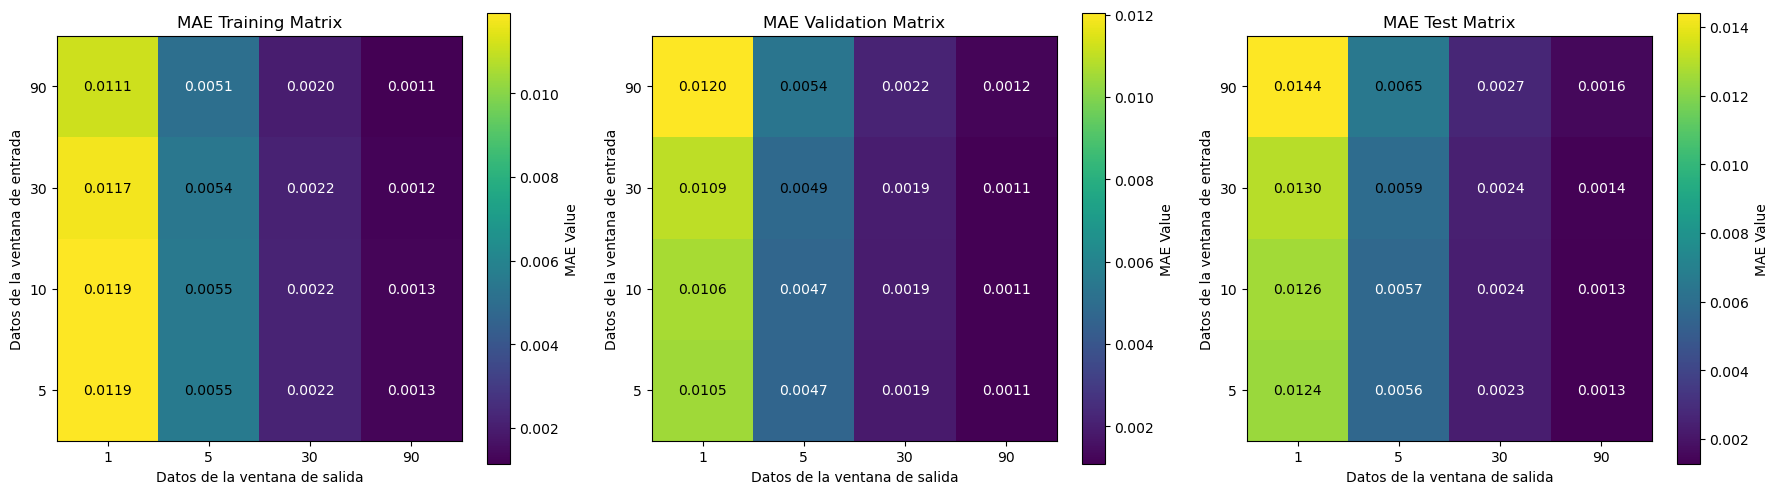

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

matrices = [mae_train_matrix, mae_val_matrix, mae_test_matrix]
titles = ['MAE Training Matrix', 'MAE Validation Matrix', 'MAE Test Matrix']

for i, ax in enumerate(axes):
    im = ax.imshow(matrices[i], cmap='viridis', origin='lower')
    
    ax.set_xlabel('Datos de la ventana de salida')
    ax.set_ylabel('Datos de la ventana de entrada')
    ax.set_title(titles[i])
    
    ax.set_xticks(np.arange(len(ventanas_salida)))
    ax.set_xticklabels(ventanas_salida)
    
    ax.set_yticks(np.arange(len(ventanas_entrada)))
    ax.set_yticklabels(ventanas_entrada)

    for y in range(matrices[i].shape[0]):
        for x in range(matrices[i].shape[1]):
            value = matrices[i][y, x]
            ax.text(x, y, f"{value:.4f}",
                    ha='center', va='center',
                    color='black' if value > np.mean(matrices[i]) else 'white')
    
    fig.colorbar(im, ax=ax, label='MAE Value')

plt.tight_layout()
plt.show()

## 3. Entrenamiento de modelos de Deep Learning

In [13]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import LSTM, GRU
from tensorflow.keras.layers import MaxPooling1D, Convolution1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dropout, Activation, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from keras import regularizers

### 3.2 Modelos de capas recurrentes (RNN)

#### 3.2.1 Modelos con 5 datos de entrada

##### 3.2.1.1. Modelo con 1 dato de salida

In [17]:
train_data_5_1, train_target_5_1 = dicc_data_train_norm[(5,1)], dicc_target_train_norm[(5,1)]
val_data_5_1, val_target_5_1 = dicc_data_val_norm[(5,1)], dicc_target_val_norm[(5,1)]
test_data_5_1, test_target_5_1 = dicc_data_test_norm[(5,1)], dicc_target_test_norm[(5,1)]

In [32]:
model_RNN_5_1 = Sequential()

model_RNN_5_1.add(LSTM(64, input_shape=(train_data_5_1.shape[1], train_data_5_1.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_5_1.add(Dropout(0.5))
#model_RNN_5_1.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_5_1.add(LSTM(32))
model_RNN_5_1.add(Dropout(0.3))

model_RNN_5_1.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_RNN_5_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001, clipnorm=1.0))

model_RNN_5_1.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 5, 64)          │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_5_1 = model_RNN_5_1.fit(train_data_5_1, train_target_5_1, validation_data=(val_data_5_1, val_target_5_1), epochs=300)

Epoch 1/300


342/342 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.7018 - val_loss: 0.6132
Epoch 2/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.6998 - val_loss: 0.6134
Epoch 3/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.6992 - val_loss: 0.6131
Epoch 4/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.6991 - val_loss: 0.6134
Epoch 5/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.6986 - val_loss: 0.6131
Epoch 6/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.6982 - val_loss: 0.6135
Epoch 7/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 0.6980 - val_loss: 0.6134
Epoch 8/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.6973 - val_loss: 0.6139
Epoch 9/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.6967 - val_loss: 0.6149
Epoch 10/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.6964 - val_loss: 0.6140
Epoch 11/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.6946 - val_loss: 0.6141
Epoch 12/300
342/342 ━━━━━━━━━━━━━━━━━━

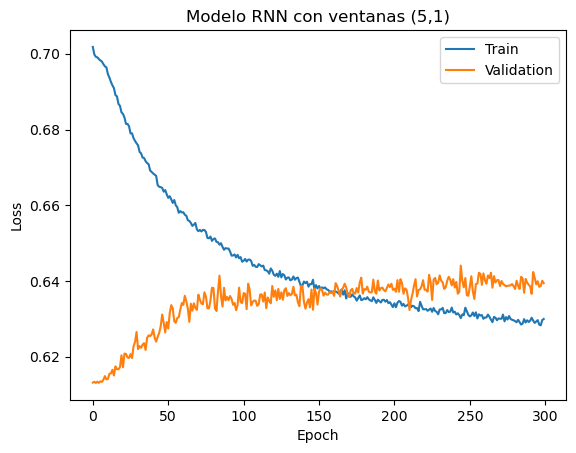

In [34]:
plt.plot(hist_RNN_5_1.history['loss'])
plt.plot(hist_RNN_5_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (5,1)')
plt.show()

In [35]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_5_1 = model_RNN_5_1.predict(train_data_5_1)
y_pred_rnn_scaled_val_5_1 = model_RNN_5_1.predict(val_data_5_1)
y_pred_rnn_scaled_test_5_1 = model_RNN_5_1.predict(test_data_5_1)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_5_1 = dicc_scaler[(5,1)]
y_pred_rnn_real_train_5_1 = scaler_y_5_1.inverse_transform(y_pred_rnn_scaled_train_5_1)
y_pred_rnn_real_val_5_1 = scaler_y_5_1.inverse_transform(y_pred_rnn_scaled_val_5_1)
y_pred_rnn_real_test_5_1 = scaler_y_5_1.inverse_transform(y_pred_rnn_scaled_test_5_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_5_1 = mean_absolute_error(dicc_target_train_reg[(5,1)], y_pred_rnn_real_train_5_1)
mae_rnn_val_5_1 = mean_absolute_error(dicc_target_val[(5,1)], y_pred_rnn_real_val_5_1)
mae_rnn_test_5_1 = mean_absolute_error(dicc_target_test[(5,1)], y_pred_rnn_real_test_5_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (5,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_5_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_5_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_5_1:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

=======   Resultados modelo RNN (5,1)   =======

MAE de la Regresión Lineal (train): 0.011929
MAE de la Red Neuronal (train):     0.010255

MAE de la Regresión Lineal (val): 0.010497
MAE de la Red Neuronal (val):     0.010809

MAE de la Regresión Lineal (test): 0.012439
MAE de la Red Neuronal (test):     0.012981



##### 3.2.1.2. Modelo con 5 datos de salida

In [36]:
train_data_5_5, train_target_5_5 = dicc_data_train_norm[(5,5)], dicc_target_train_norm[(5,5)]
val_data_5_5, val_target_5_5 = dicc_data_val_norm[(5,5)], dicc_target_val_norm[(5,5)]
test_data_5_5, test_target_5_5 = dicc_data_test_norm[(5,5)], dicc_target_test_norm[(5,5)]

In [55]:
model_RNN_5_5 = Sequential()

model_RNN_5_5.add(LSTM(64, input_shape=(train_data_5_5.shape[1], train_data_5_5.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_5_5.add(Dropout(0.5))
#model_RNN_5_5.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_5_5.add(LSTM(32))
model_RNN_5_5.add(Dropout(0.3))
model_RNN_5_5.add(Dense(train_target_5_5.shape[1], activation='linear'))

model_RNN_5_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_5_5.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_25 (LSTM)                  │ (None, 5, 64)          │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_5_5 = model_RNN_5_5.fit(train_data_5_5, train_target_5_5, validation_data=(val_data_5_5, val_target_5_5), epochs=300)

Epoch 1/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - loss: 0.7261 - val_loss: 0.6112
Epoch 2/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.7231 - val_loss: 0.6119
Epoch 3/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.7207 - val_loss: 0.6126
Epoch 4/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.7173 - val_loss: 0.6132
Epoch 5/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.7129 - val_loss: 0.6159
Epoch 6/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.7073 - val_loss: 0.6196
Epoch 7/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.7023 - val_loss: 0.6208
Epoch 8/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.6976 - val_loss: 0.6242
Epoch 9/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.6930 - val_loss: 0.6260
Epoch 10/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.6876 - val_loss: 0.6210
Epoch 11/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.6860 - val_loss: 0.6258
Epoch 12/300
342/342 ━━━━━━━━

In [ ]:
aux_history = hist_RNN_5_5

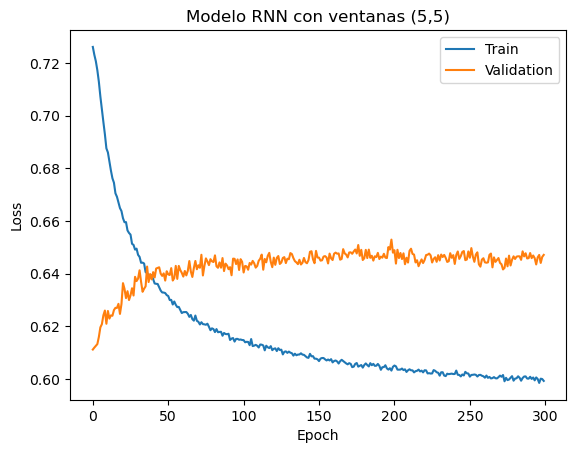

In [57]:
plt.plot(hist_RNN_5_5.history['loss'])
plt.plot(hist_RNN_5_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (5,5)')
plt.show()

In [44]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_5_5 = model_RNN_5_5.predict(train_data_5_5)
y_pred_rnn_scaled_val_5_5 = model_RNN_5_5.predict(val_data_5_5)
y_pred_rnn_scaled_test_5_5 = model_RNN_5_5.predict(test_data_5_5)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_5_5 = dicc_scaler[(5,5)]
y_pred_rnn_real_train_5_5 = scaler_y_5_5.inverse_transform(y_pred_rnn_scaled_train_5_5)
y_pred_rnn_real_val_5_5 = scaler_y_5_5.inverse_transform(y_pred_rnn_scaled_val_5_5)
y_pred_rnn_real_test_5_5 = scaler_y_5_5.inverse_transform(y_pred_rnn_scaled_test_5_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_5_5 = mean_absolute_error(dicc_target_train_reg[(5,5)], y_pred_rnn_real_train_5_5)
mae_rnn_val_5_5 = mean_absolute_error(dicc_target_val[(5,5)], y_pred_rnn_real_val_5_5)
mae_rnn_test_5_5 = mean_absolute_error(dicc_target_test[(5,5)], y_pred_rnn_real_test_5_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (5,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_5_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_5_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_5_5:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

=======   Resultados modelo RNN (5,5)   =======

MAE de la Regresión Lineal (train): 0.005537
MAE de la Red Neuronal (train):     0.004468

MAE de la Regresión Lineal (val): 0.004675
MAE de la Red Neuronal (val):     0.005165

MAE de la Regresión Lineal (test): 0.005641
MAE de la Red Neuronal (test):     0.006343



##### 3.2.1.3. Modelo con 30 datos de salida

In [58]:
train_data_5_30, train_target_5_30 = dicc_data_train_norm[(5,30)], dicc_target_train_norm[(5,30)]
val_data_5_30, val_target_5_30 = dicc_data_val_norm[(5,30)], dicc_target_val_norm[(5,30)]
test_data_5_30, test_target_5_30 = dicc_data_test_norm[(5,30)], dicc_target_test_norm[(5,30)]

In [59]:
model_RNN_5_30 = Sequential()

model_RNN_5_30.add(LSTM(64, input_shape=(train_data_5_30.shape[1], train_data_5_30.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_5_30.add(Dropout(0.5))
#model_RNN_5_30.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_5_30.add(LSTM(32))
model_RNN_5_30.add(Dropout(0.3))

model_RNN_5_30.add(Dense(train_target_5_30.shape[1], activation='linear'))

model_RNN_5_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_5_30.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_27 (LSTM)                  │ (None, 5, 64)          │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_5_30 = model_RNN_5_30.fit(train_data_5_30, train_target_5_30, validation_data=(val_data_5_30, val_target_5_30), epochs=300)

Epoch 1/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.7529 - val_loss: 0.6454
Epoch 2/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.7481 - val_loss: 0.6463
Epoch 3/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.7425 - val_loss: 0.6482
Epoch 4/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.7361 - val_loss: 0.6523
Epoch 5/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.7274 - val_loss: 0.6548
Epoch 6/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.7201 - val_loss: 0.6600
Epoch 7/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.7130 - val_loss: 0.6592
Epoch 8/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.7069 - val_loss: 0.6648
Epoch 9/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.7023 - val_loss: 0.6697
Epoch 10/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.6958 - val_loss: 0.6632
Epoch 11/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.6912 - val_loss: 0.6682
Epoch 12/300
341/341 ━━━━━━━

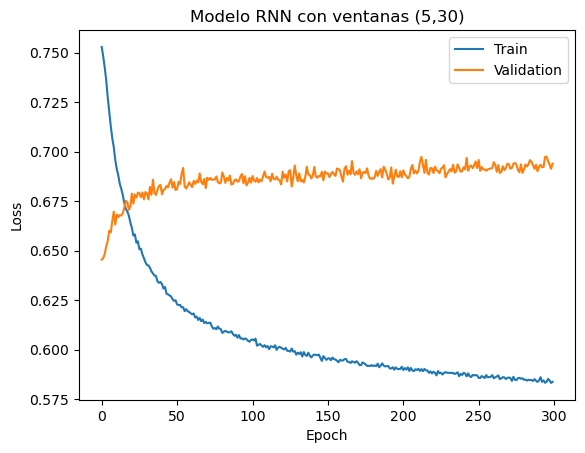

In [63]:
plt.plot(hist_RNN_5_30.history['loss'])
plt.plot(hist_RNN_5_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (5,30)')
plt.show()

In [64]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_5_30 = model_RNN_5_30.predict(train_data_5_30)
y_pred_rnn_scaled_val_5_30 = model_RNN_5_30.predict(val_data_5_30)
y_pred_rnn_scaled_test_5_30 = model_RNN_5_30.predict(test_data_5_30)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_5_30 = dicc_scaler[(5,30)]
y_pred_rnn_real_train_5_30 = scaler_y_5_30.inverse_transform(y_pred_rnn_scaled_train_5_30)
y_pred_rnn_real_val_5_30 = scaler_y_5_30.inverse_transform(y_pred_rnn_scaled_val_5_30)
y_pred_rnn_real_test_5_30 = scaler_y_5_30.inverse_transform(y_pred_rnn_scaled_test_5_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_5_30 = mean_absolute_error(dicc_target_train_reg[(5,30)], y_pred_rnn_real_train_5_30)
mae_rnn_val_5_30 = mean_absolute_error(dicc_target_val[(5,30)], y_pred_rnn_real_val_5_30)
mae_rnn_test_5_30 = mean_absolute_error(dicc_target_test[(5,30)], y_pred_rnn_real_test_5_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (5,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_5_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_5_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_5_30:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

=======   Resultados modelo RNN (5,30)   =======

MAE de la Regresión Lineal (train): 0.002226
MAE de la Red Neuronal (train):     0.001584

MAE de la Regresión Lineal (val): 0.001901
MAE de la Red Neuronal (val):     0.002036

MAE de la Regresión Lineal (test): 0.002342
MAE de la Red Neuronal (test):     0.002445



##### 3.2.1.4. Modelo con 90 datos de salida

In [ ]:
train_data_5_90, train_target_5_90 = dicc_data_train_norm[(5,90)], dicc_target_train_norm[(5,90)]
val_data_5_90, val_target_5_90 = dicc_data_val_norm[(5,90)], dicc_target_val_norm[(5,90)]
test_data_5_90, test_target_5_90 = dicc_data_test_norm[(5,90)], dicc_target_test_norm[(5,90)]

In [51]:
model_RNN_5_90 = Sequential()

model_RNN_5_90.add(LSTM(64, input_shape=(train_data_5_90.shape[1], train_data_5_90.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_5_90.add(Dropout(0.3))
#model_RNN_5_90.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_5_90.add(LSTM(32))
model_RNN_5_90.add(Dense(train_target_5_90.shape[1], activation='linear'))

model_RNN_5_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_5_90.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 5, 64)          │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_5_90 = model_RNN_5_90.fit(train_data_5_90, train_target_5_90, validation_data=(val_data_5_90, val_target_5_90), epochs=300)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - loss: 0.0081 - val_loss: 0.0014
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 12/50
340/340 ━━━━━━━━━━━━━━━━━━━━

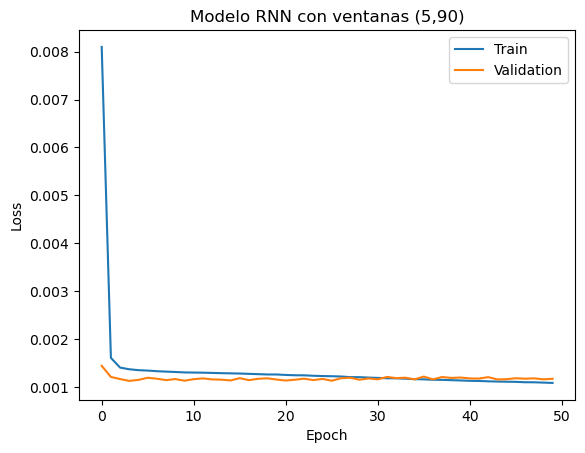

In [ ]:
plt.plot(hist_RNN_5_90.history['loss'])
plt.plot(hist_RNN_5_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (5,90)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_5_90 = model_RNN_5_90.predict(train_data_5_90)
y_pred_rnn_scaled_val_5_90 = model_RNN_5_90.predict(val_data_5_90)
y_pred_rnn_scaled_test_5_90 = model_RNN_5_90.predict(test_data_5_90)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_5_90 = dicc_scaler[(5,90)]
y_pred_rnn_real_train_5_90 = scaler_y_5_90.inverse_transform(y_pred_rnn_scaled_train_5_90)
y_pred_rnn_real_val_5_90 = scaler_y_5_90.inverse_transform(y_pred_rnn_scaled_val_5_90)
y_pred_rnn_real_test_5_90 = scaler_y_5_90.inverse_transform(y_pred_rnn_scaled_test_5_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_5_90 = mean_absolute_error(dicc_target_train_reg[(5,90)], y_pred_rnn_real_train_5_90)
mae_rnn_val_5_90 = mean_absolute_error(dicc_target_val[(5,90)], y_pred_rnn_real_val_5_90)
mae_rnn_test_5_90 = mean_absolute_error(dicc_target_test[(5,90)], y_pred_rnn_real_test_5_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (5,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_5_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_5_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_5_90:.6f}")
print()

#### 3.2.2 Modelos con 10 datos de entrada

##### 3.2.2.1. Modelo con 1 dato de salida

In [ ]:
train_data_10_1, train_target_10_1 = dicc_data_train_norm[(10,1)], dicc_target_train_norm[(10,1)]
val_data_10_1, val_target_10_1 = dicc_data_val_norm[(10,1)], dicc_target_val_norm[(10,1)]
test_data_10_1, test_target_10_1 = dicc_data_test_norm[(10,1)], dicc_target_test_norm[(10,1)]

In [55]:
model_RNN_10_1 = Sequential()

model_RNN_10_1.add(LSTM(64, input_shape=(train_data_10_1.shape[1], train_data_10_1.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_10_1.add(Dropout(0.3))
#model_RNN_10_1.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_10_1.add(LSTM(32))
model_RNN_10_1.add(Dense(train_target_10_1.shape[1], activation='linear'))

model_RNN_10_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_10_1.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 10, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_10_1 = model_RNN_10_1.fit(train_data_10_1, train_target_10_1, validation_data=(val_data_10_1, val_target_10_1), epochs=300)

Epoch 1/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.0172 - val_loss: 0.0106
Epoch 2/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0124 - val_loss: 0.0105
Epoch 3/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 4/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 5/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 6/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 7/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 8/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 9/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 10/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 11/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 12/50
342/342 ━━━━━━━━━━━━━━━━━━━

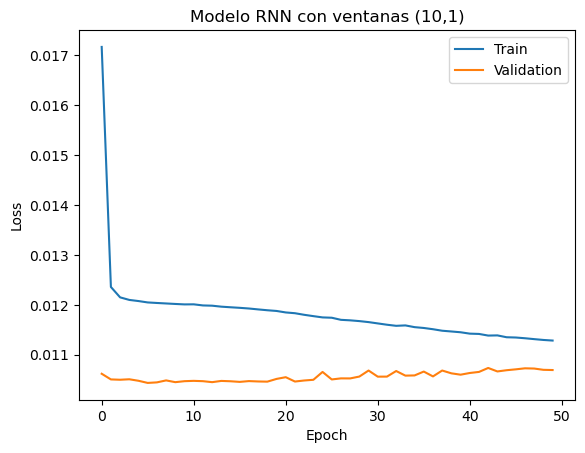

In [ ]:
plt.plot(hist_RNN_10_1.history['loss'])
plt.plot(hist_RNN_10_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (10,1)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_10_1 = model_RNN_10_1.predict(train_data_10_1)
y_pred_rnn_scaled_val_10_1 = model_RNN_10_1.predict(val_data_10_1)
y_pred_rnn_scaled_test_10_1 = model_RNN_10_1.predict(test_data_10_1)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_10_1 = dicc_scaler[(10,1)]
y_pred_rnn_real_train_10_1 = scaler_y_10_1.inverse_transform(y_pred_rnn_scaled_train_10_1)
y_pred_rnn_real_val_10_1 = scaler_y_10_1.inverse_transform(y_pred_rnn_scaled_val_10_1)
y_pred_rnn_real_test_10_1 = scaler_y_10_1.inverse_transform(y_pred_rnn_scaled_test_10_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_10_1 = mean_absolute_error(dicc_target_train_reg[(10,1)], y_pred_rnn_real_train_10_1)
mae_rnn_val_10_1 = mean_absolute_error(dicc_target_val[(10,1)], y_pred_rnn_real_val_10_1)
mae_rnn_test_10_1 = mean_absolute_error(dicc_target_test[(10,1)], y_pred_rnn_real_test_10_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (10,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_10_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_10_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_10_1:.6f}")
print()

##### 3.2.2.2. Modelo con 5 datos de salida

In [ ]:
train_data_10_5, train_target_10_5 = dicc_data_train_norm[(10,5)], dicc_target_train_norm[(10,5)]
val_data_10_5, val_target_10_5 = dicc_data_val_norm[(10,5)], dicc_target_val_norm[(10,5)]
test_data_10_5, test_target_10_5 = dicc_data_test_norm[(10,5)], dicc_target_test_norm[(10,5)]

In [59]:
model_RNN_10_5 = Sequential()

model_RNN_10_5.add(LSTM(64, input_shape=(train_data_10_5.shape[1], train_data_10_5.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_10_5.add(Dropout(0.3))
#model_RNN_10_5.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_10_5.add(LSTM(32))
model_RNN_10_5.add(Dense(train_target_10_5.shape[1], activation='linear'))

model_RNN_10_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_10_5.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_34 (LSTM)                  │ (None, 10, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_10_5 = model_RNN_10_5.fit(train_data_10_5, train_target_10_5, validation_data=(val_data_10_5, val_target_10_5), epochs=300)

Epoch 1/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - loss: 0.0123 - val_loss: 0.0049
Epoch 2/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0059 - val_loss: 0.0048
Epoch 3/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0057 - val_loss: 0.0048
Epoch 4/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 5/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 6/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 7/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 8/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 9/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0055 - val_loss: 0.0049
Epoch 10/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0054 - val_loss: 0.0048
Epoch 11/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0054 - val_loss: 0.0048
Epoch 12/50
342/342 ━━━━━━━━━━━━━━━━━━

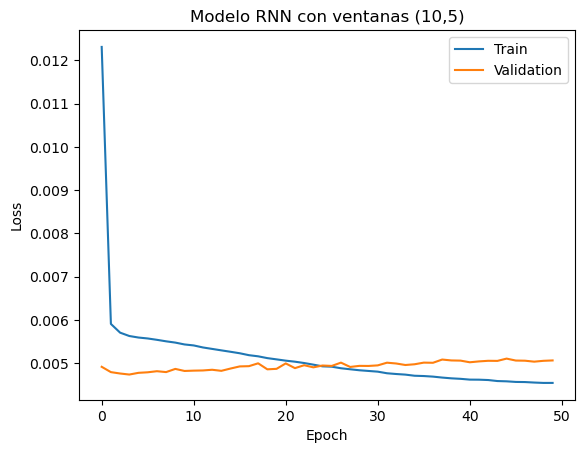

In [ ]:
plt.plot(hist_RNN_10_5.history['loss'])
plt.plot(hist_RNN_10_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (10,5)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_10_5 = model_RNN_10_5.predict(train_data_10_5)
y_pred_rnn_scaled_val_10_5 = model_RNN_10_5.predict(val_data_10_5)
y_pred_rnn_scaled_test_10_5 = model_RNN_10_5.predict(test_data_10_5)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_10_5 = dicc_scaler[(10,5)]
y_pred_rnn_real_train_10_5 = scaler_y_10_5.inverse_transform(y_pred_rnn_scaled_train_10_5)
y_pred_rnn_real_val_10_5 = scaler_y_10_5.inverse_transform(y_pred_rnn_scaled_val_10_5)
y_pred_rnn_real_test_10_5 = scaler_y_10_5.inverse_transform(y_pred_rnn_scaled_test_10_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_10_5 = mean_absolute_error(dicc_target_train_reg[(10,5)], y_pred_rnn_real_train_10_5)
mae_rnn_val_10_5 = mean_absolute_error(dicc_target_val[(10,5)], y_pred_rnn_real_val_10_5)
mae_rnn_test_10_5 = mean_absolute_error(dicc_target_test[(10,5)], y_pred_rnn_real_test_10_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (10,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_10_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_10_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_10_5:.6f}")
print()

##### 3.2.2.3. Modelo con 30 datos de salida

In [ ]:
train_data_10_30, train_target_10_30 = dicc_data_train_norm[(10,30)], dicc_target_train_norm[(10,30)]
val_data_10_30, val_target_10_30 = dicc_data_val_norm[(10,30)], dicc_target_val_norm[(10,30)]
test_data_10_30, test_target_10_30 = dicc_data_test_norm[(10,30)], dicc_target_test_norm[(10,30)]

In [63]:
model_RNN_10_30 = Sequential()

model_RNN_10_30.add(LSTM(64, input_shape=(train_data_10_30.shape[1], train_data_10_30.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_10_30.add(Dropout(0.3))
#model_RNN_10_30.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_10_30.add(LSTM(32))
model_RNN_10_30.add(Dense(train_target_10_30.shape[1], activation='linear'))

model_RNN_10_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_10_30.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_36 (LSTM)                  │ (None, 10, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_37 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_10_30 = model_RNN_10_30.fit(train_data_10_30, train_target_10_30, validation_data=(val_data_10_30, val_target_10_30), epochs=300)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - loss: 0.0095 - val_loss: 0.0022
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0026 - val_loss: 0.0020
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 12/50
341/341 ━━━━━━━━━━━━━━━━━━━━

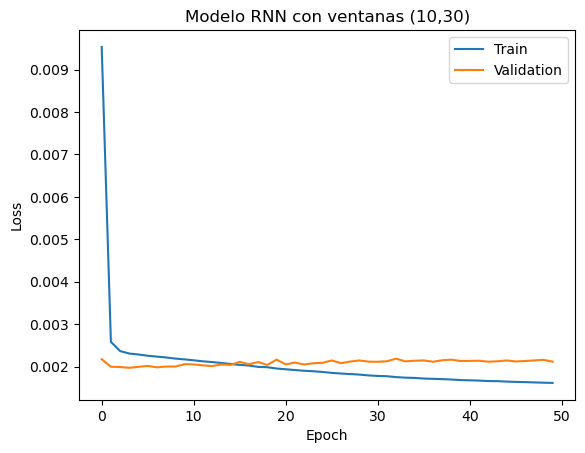

In [ ]:
plt.plot(hist_RNN_10_30.history['loss'])
plt.plot(hist_RNN_10_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (10,30)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_10_30 = model_RNN_10_30.predict(train_data_10_30)
y_pred_rnn_scaled_val_10_30 = model_RNN_10_30.predict(val_data_10_30)
y_pred_rnn_scaled_test_10_30 = model_RNN_10_30.predict(test_data_10_30)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_10_30 = dicc_scaler[(10,30)]
y_pred_rnn_real_train_10_30 = scaler_y_10_30.inverse_transform(y_pred_rnn_scaled_train_10_30)
y_pred_rnn_real_val_10_30 = scaler_y_10_30.inverse_transform(y_pred_rnn_scaled_val_10_30)
y_pred_rnn_real_test_10_30 = scaler_y_10_30.inverse_transform(y_pred_rnn_scaled_test_10_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_10_30 = mean_absolute_error(dicc_target_train_reg[(10,30)], y_pred_rnn_real_train_10_30)
mae_rnn_val_10_30 = mean_absolute_error(dicc_target_val[(10,30)], y_pred_rnn_real_val_10_30)
mae_rnn_test_10_30 = mean_absolute_error(dicc_target_test[(10,30)], y_pred_rnn_real_test_10_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (10,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_10_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_10_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_10_30:.6f}")
print()

##### 3.2.2.4. Modelo con 90 datos de salida

In [ ]:
train_data_10_90, train_target_10_90 = dicc_data_train_norm[(10,90)], dicc_target_train_norm[(10,90)]
val_data_10_90, val_target_10_90 = dicc_data_val_norm[(10,90)], dicc_target_val_norm[(10,90)]
test_data_10_90, test_target_10_90 = dicc_data_test_norm[(10,90)], dicc_target_test_norm[(10,90)]

In [67]:
model_RNN_10_90 = Sequential()

model_RNN_10_90.add(LSTM(64, input_shape=(train_data_10_90.shape[1], train_data_10_90.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_10_90.add(Dropout(0.3))
#model_RNN_10_90.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_10_90.add(LSTM(32))
model_RNN_10_90.add(Dense(train_target_10_90.shape[1], activation='linear'))

model_RNN_10_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_10_90.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_38 (LSTM)                  │ (None, 10, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_39 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_10_90 = model_RNN_10_90.fit(train_data_10_90, train_target_10_90, validation_data=(val_data_10_90, val_target_10_90), epochs=300)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - loss: 0.0087 - val_loss: 0.0015
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 12/50
340/340 ━━━━━━━━━━━━━━━━

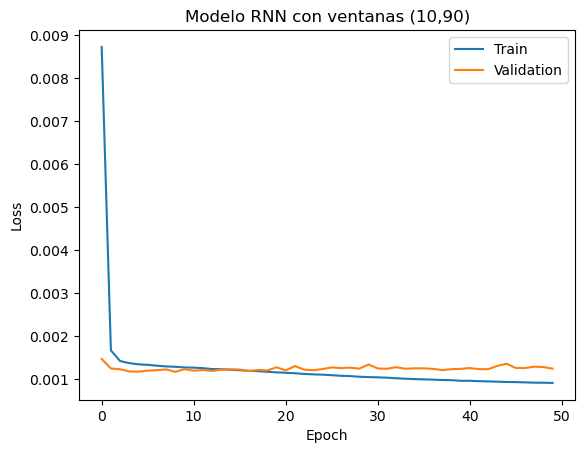

In [ ]:
plt.plot(hist_RNN_10_90.history['loss'])
plt.plot(hist_RNN_10_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (10,90)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_10_90 = model_RNN_10_90.predict(train_data_10_90)
y_pred_rnn_scaled_val_10_90 = model_RNN_10_90.predict(val_data_10_90)
y_pred_rnn_scaled_test_10_90 = model_RNN_10_90.predict(test_data_10_90)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_10_90 = dicc_scaler[(10,90)]
y_pred_rnn_real_train_10_90 = scaler_y_10_90.inverse_transform(y_pred_rnn_scaled_train_10_90)
y_pred_rnn_real_val_10_90 = scaler_y_10_90.inverse_transform(y_pred_rnn_scaled_val_10_90)
y_pred_rnn_real_test_10_90 = scaler_y_10_90.inverse_transform(y_pred_rnn_scaled_test_10_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_10_90 = mean_absolute_error(dicc_target_train_reg[(10,90)], y_pred_rnn_real_train_10_90)
mae_rnn_val_10_90 = mean_absolute_error(dicc_target_val[(10,90)], y_pred_rnn_real_val_10_90)
mae_rnn_test_10_90 = mean_absolute_error(dicc_target_test[(10,90)], y_pred_rnn_real_test_10_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (10,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_10_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_10_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_10_90:.6f}")
print()

#### 3.2.3 Modelos con 30 datos de entrada

##### 3.2.3.1. Modelo con 1 dato de salida

In [ ]:
train_data_30_1, train_target_30_1 = dicc_data_train_norm[(30,1)], dicc_target_train_norm[(30,1)]
val_data_30_1, val_target_30_1 = dicc_data_val_norm[(30,1)], dicc_target_val_norm[(30,1)]
test_data_30_1, test_target_30_1 = dicc_data_test_norm[(30,1)], dicc_target_test_norm[(30,1)]

In [71]:
model_RNN_30_1 = Sequential()

model_RNN_30_1.add(LSTM(64, input_shape=(train_data_30_1.shape[1], train_data_30_1.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_30_1.add(Dropout(0.3))
#model_RNN_30_1.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_30_1.add(LSTM(32))
model_RNN_30_1.add(Dense(train_target_30_1.shape[1], activation='linear'))

model_RNN_30_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_30_1.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_40 (LSTM)                  │ (None, 30, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_30_1 = model_RNN_30_1.fit(train_data_30_1, train_target_30_1, validation_data=(val_data_30_1, val_target_30_1), epochs=300)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - loss: 0.0177 - val_loss: 0.0107
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0124 - val_loss: 0.0106
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - loss: 0.0122 - val_loss: 0.0106
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0120 - val_loss: 0.0106
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 12/50
341/341 ━━━━━━━━━━

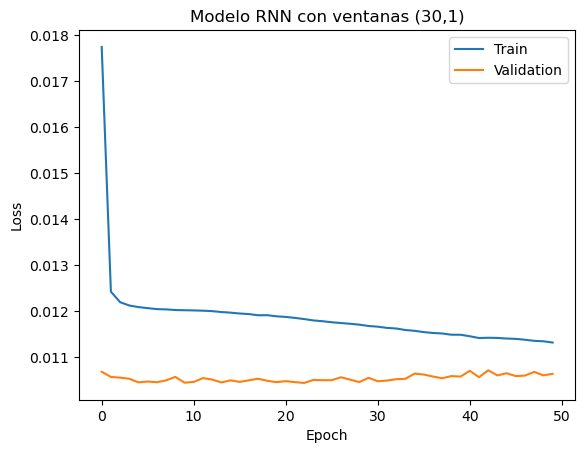

In [ ]:
plt.plot(hist_RNN_30_1.history['loss'])
plt.plot(hist_RNN_30_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (30,1)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_30_1 = model_RNN_30_1.predict(train_data_30_1)
y_pred_rnn_scaled_val_30_1 = model_RNN_30_1.predict(val_data_30_1)
y_pred_rnn_scaled_test_30_1 = model_RNN_30_1.predict(test_data_30_1)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_30_1 = dicc_scaler[(30,1)]
y_pred_rnn_real_train_30_1 = scaler_y_30_1.inverse_transform(y_pred_rnn_scaled_train_30_1)
y_pred_rnn_real_val_30_1 = scaler_y_30_1.inverse_transform(y_pred_rnn_scaled_val_30_1)
y_pred_rnn_real_test_30_1 = scaler_y_30_1.inverse_transform(y_pred_rnn_scaled_test_30_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_30_1 = mean_absolute_error(dicc_target_train_reg[(30,1)], y_pred_rnn_real_train_30_1)
mae_rnn_val_30_1 = mean_absolute_error(dicc_target_val[(30,1)], y_pred_rnn_real_val_30_1)
mae_rnn_test_30_1 = mean_absolute_error(dicc_target_test[(30,1)], y_pred_rnn_real_test_30_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (30,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_30_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_30_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_30_1:.6f}")
print()

##### 3.2.3.2. Modelo con 5 datos de salida

In [ ]:
train_data_30_5, train_target_30_5 = dicc_data_train_norm[(30,5)], dicc_target_train_norm[(30,5)]
val_data_30_5, val_target_30_5 = dicc_data_val_norm[(30,5)], dicc_target_val_norm[(30,5)]
test_data_30_5, test_target_30_5 = dicc_data_test_norm[(30,5)], dicc_target_test_norm[(30,5)]

In [75]:
model_RNN_30_5 = Sequential()

model_RNN_30_5.add(LSTM(64, input_shape=(train_data_30_5.shape[1], train_data_30_5.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_30_5.add(Dropout(0.3))
#model_RNN_30_5.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_30_5.add(LSTM(32))
model_RNN_30_5.add(Dense(train_target_30_5.shape[1], activation='linear'))

model_RNN_30_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_30_5.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_42 (LSTM)                  │ (None, 30, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_43 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_30_5 = model_RNN_30_5.fit(train_data_30_5, train_target_30_5, validation_data=(val_data_30_5, val_target_30_5), epochs=300)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - loss: 0.0118 - val_loss: 0.0050
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0059 - val_loss: 0.0048
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0057 - val_loss: 0.0048
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0054 - val_loss: 0.0049
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0054 - val_loss: 0.0049
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0054 - val_loss: 0.0048
Epoch 12/50
341/341 ━━━━━━━━━━

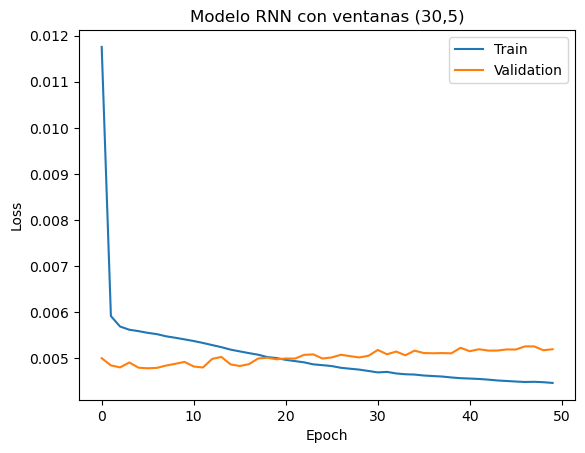

In [ ]:
plt.plot(hist_RNN_30_5.history['loss'])
plt.plot(hist_RNN_30_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (30,5)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_30_5 = model_RNN_30_5.predict(train_data_30_5)
y_pred_rnn_scaled_val_30_5 = model_RNN_30_5.predict(val_data_30_5)
y_pred_rnn_scaled_test_30_5 = model_RNN_30_5.predict(test_data_30_5)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_30_5 = dicc_scaler[(30,5)]
y_pred_rnn_real_train_30_5 = scaler_y_30_5.inverse_transform(y_pred_rnn_scaled_train_30_5)
y_pred_rnn_real_val_30_5 = scaler_y_30_5.inverse_transform(y_pred_rnn_scaled_val_30_5)
y_pred_rnn_real_test_30_5 = scaler_y_30_5.inverse_transform(y_pred_rnn_scaled_test_30_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_30_5 = mean_absolute_error(dicc_target_train_reg[(30,5)], y_pred_rnn_real_train_30_5)
mae_rnn_val_30_5 = mean_absolute_error(dicc_target_val[(30,5)], y_pred_rnn_real_val_30_5)
mae_rnn_test_30_5 = mean_absolute_error(dicc_target_test[(30,5)], y_pred_rnn_real_test_30_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (30,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_30_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_30_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_30_5:.6f}")
print()

##### 3.2.3.3. Modelo con 30 datos de salida

In [ ]:
train_data_30_30, train_target_30_30 = dicc_data_train_norm[(30,30)], dicc_target_train_norm[(30,30)]
val_data_30_30, val_target_30_30 = dicc_data_val_norm[(30,30)], dicc_target_val_norm[(30,30)]
test_data_30_30, test_target_30_30 = dicc_data_test_norm[(30,30)], dicc_target_test_norm[(30,30)]

In [79]:
model_RNN_30_30 = Sequential()

model_RNN_30_30.add(LSTM(64, input_shape=(train_data_30_30.shape[1], train_data_30_30.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_30_30.add(Dropout(0.3))
#model_RNN_30_30.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_30_30.add(LSTM(32))
model_RNN_30_30.add(Dense(train_target_30_30.shape[1], activation='linear'))

model_RNN_30_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_30_30.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_44 (LSTM)                  │ (None, 30, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_45 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_30_30 = model_RNN_30_30.fit(train_data_30_30, train_target_30_30, validation_data=(val_data_30_30, val_target_30_30), epochs=300)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - loss: 0.0099 - val_loss: 0.0025
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 12/50
341/341 ━━━━━━━━━━

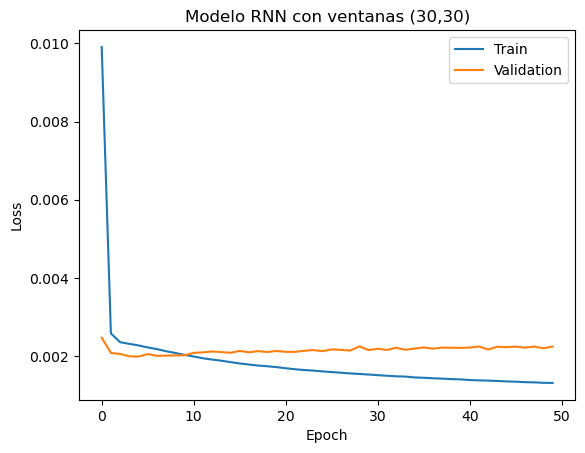

In [ ]:
plt.plot(hist_RNN_30_30.history['loss'])
plt.plot(hist_RNN_30_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (30,30)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_30_30 = model_RNN_30_30.predict(train_data_30_30)
y_pred_rnn_scaled_val_30_30 = model_RNN_30_30.predict(val_data_30_30)
y_pred_rnn_scaled_test_30_30 = model_RNN_30_30.predict(test_data_30_30)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_30_30 = dicc_scaler[(30,30)]
y_pred_rnn_real_train_30_30 = scaler_y_30_30.inverse_transform(y_pred_rnn_scaled_train_30_30)
y_pred_rnn_real_val_30_30 = scaler_y_30_30.inverse_transform(y_pred_rnn_scaled_val_30_30)
y_pred_rnn_real_test_30_30 = scaler_y_30_30.inverse_transform(y_pred_rnn_scaled_test_30_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_30_30 = mean_absolute_error(dicc_target_train_reg[(30,30)], y_pred_rnn_real_train_30_30)
mae_rnn_val_30_30 = mean_absolute_error(dicc_target_val[(30,30)], y_pred_rnn_real_val_30_30)
mae_rnn_test_30_30 = mean_absolute_error(dicc_target_test[(30,30)], y_pred_rnn_real_test_30_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (30,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_30_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_30_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_30_30:.6f}")
print()

##### 3.2.3.4. Modelo con 90 datos de salida

In [ ]:
train_data_30_90, train_target_30_90 = dicc_data_train_norm[(30,90)], dicc_target_train_norm[(30,90)]
val_data_30_90, val_target_30_90 = dicc_data_val_norm[(30,90)], dicc_target_val_norm[(30,90)]
test_data_30_90, test_target_30_90 = dicc_data_test_norm[(30,90)], dicc_target_test_norm[(30,90)]

In [83]:
model_RNN_30_90 = Sequential()

model_RNN_30_90.add(LSTM(64, input_shape=(train_data_30_90.shape[1], train_data_30_90.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_30_90.add(Dropout(0.3))
#model_RNN_30_90.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_30_90.add(LSTM(32))
model_RNN_30_90.add(Dense(train_target_30_90.shape[1], activation='linear'))

model_RNN_30_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_30_90.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_46 (LSTM)                  │ (None, 30, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_47 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_30_90 = model_RNN_30_90.fit(train_data_30_90, train_target_30_90, validation_data=(val_data_30_90, val_target_30_90), epochs=300)

Epoch 1/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - loss: 0.0096 - val_loss: 0.0016
Epoch 2/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 3/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 4/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 5/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 6/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 8/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 9/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 10/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 11/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 12/50
339/339 ━━━━━━━━━━

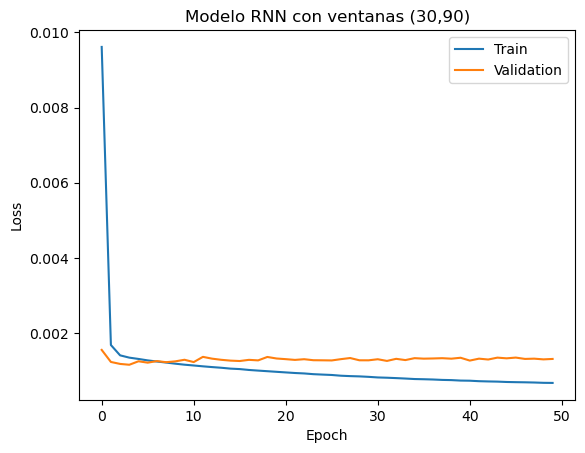

In [ ]:
plt.plot(hist_RNN_30_90.history['loss'])
plt.plot(hist_RNN_30_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (30,90)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_30_90 = model_RNN_30_90.predict(train_data_30_90)
y_pred_rnn_scaled_val_30_90 = model_RNN_30_90.predict(val_data_30_90)
y_pred_rnn_scaled_test_30_90 = model_RNN_30_90.predict(test_data_30_90)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_30_90 = dicc_scaler[(30,90)]
y_pred_rnn_real_train_30_90 = scaler_y_30_90.inverse_transform(y_pred_rnn_scaled_train_30_90)
y_pred_rnn_real_val_30_90 = scaler_y_30_90.inverse_transform(y_pred_rnn_scaled_val_30_90)
y_pred_rnn_real_test_30_90 = scaler_y_30_90.inverse_transform(y_pred_rnn_scaled_test_30_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_30_90 = mean_absolute_error(dicc_target_train_reg[(30,90)], y_pred_rnn_real_train_30_90)
mae_rnn_val_30_90 = mean_absolute_error(dicc_target_val[(30,90)], y_pred_rnn_real_val_30_90)
mae_rnn_test_30_90 = mean_absolute_error(dicc_target_test[(30,90)], y_pred_rnn_real_test_30_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (30,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_30_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_30_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_30_90:.6f}")
print()

#### 3.2.4 Modelos con 90 datos de entrada

##### 3.2.4.1. Modelo con 1 dato de salida

In [ ]:
train_data_90_1, train_target_90_1 = dicc_data_train_norm[(90,1)], dicc_target_train_norm[(90,1)]
val_data_90_1, val_target_90_1 = dicc_data_val_norm[(90,1)], dicc_target_val_norm[(90,1)]
test_data_90_1, test_target_90_1 = dicc_data_test_norm[(90,1)], dicc_target_test_norm[(90,1)]

In [87]:
model_RNN_90_1 = Sequential()

model_RNN_90_1.add(LSTM(64, input_shape=(train_data_90_1.shape[1], train_data_90_1.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_90_1.add(Dropout(0.3))
#model_RNN_90_1.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_90_1.add(LSTM(32))
model_RNN_90_1.add(Dense(train_target_90_1.shape[1], activation='linear'))

model_RNN_90_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_90_1.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_48 (LSTM)                  │ (None, 90, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_90_1 = model_RNN_90_1.fit(train_data_90_1, train_target_90_1, validation_data=(val_data_90_1, val_target_90_1), epochs=300)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 48s 120ms/step - loss: 0.0173 - val_loss: 0.0107
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 40s 117ms/step - loss: 0.0124 - val_loss: 0.0107
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 40s 116ms/step - loss: 0.0122 - val_loss: 0.0105
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 39s 116ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 40s 118ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 111ms/step - loss: 0.0121 - val_loss: 0.0104
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 113ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 112ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 12/50
340/340

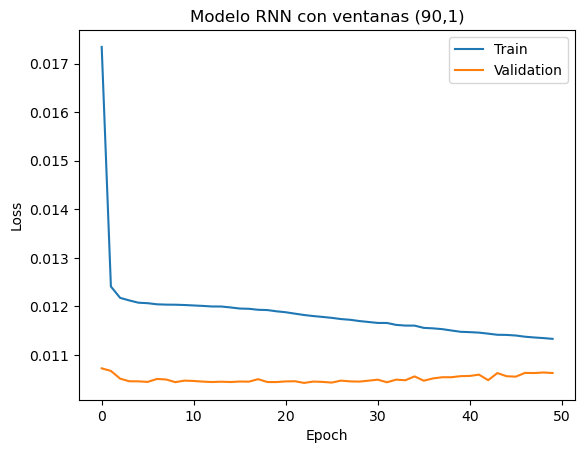

In [ ]:
plt.plot(hist_RNN_90_1.history['loss'])
plt.plot(hist_RNN_90_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (90,1)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_90_1 = model_RNN_90_1.predict(train_data_90_1)
y_pred_rnn_scaled_val_90_1 = model_RNN_90_1.predict(val_data_90_1)
y_pred_rnn_scaled_test_90_1 = model_RNN_90_1.predict(test_data_90_1)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_90_1 = dicc_scaler[(90,1)]
y_pred_rnn_real_train_90_1 = scaler_y_90_1.inverse_transform(y_pred_rnn_scaled_train_90_1)
y_pred_rnn_real_val_90_1 = scaler_y_90_1.inverse_transform(y_pred_rnn_scaled_val_90_1)
y_pred_rnn_real_test_90_1 = scaler_y_90_1.inverse_transform(y_pred_rnn_scaled_test_90_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_90_1 = mean_absolute_error(dicc_target_train_reg[(90,1)], y_pred_rnn_real_train_90_1)
mae_rnn_val_90_1 = mean_absolute_error(dicc_target_val[(90,1)], y_pred_rnn_real_val_90_1)
mae_rnn_test_90_1 = mean_absolute_error(dicc_target_test[(90,1)], y_pred_rnn_real_test_90_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (90,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_90_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_90_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_90_1:.6f}")
print()

##### 3.2.4.2. Modelo con 5 datos de salida

In [ ]:
train_data_90_5, train_target_90_5 = dicc_data_train_norm[(90,5)], dicc_target_train_norm[(90,5)]
val_data_90_5, val_target_90_5 = dicc_data_val_norm[(90,5)], dicc_target_val_norm[(90,5)]
test_data_90_5, test_target_90_5 = dicc_data_test_norm[(90,5)], dicc_target_test_norm[(90,5)]

In [91]:
model_RNN_90_5 = Sequential()

model_RNN_90_5.add(LSTM(64, input_shape=(train_data_90_5.shape[1], train_data_90_5.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_90_5.add(Dropout(0.3))
#model_RNN_90_5.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_90_5.add(LSTM(32))
model_RNN_90_5.add(Dense(train_target_90_5.shape[1], activation='linear'))

model_RNN_90_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_90_5.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_50 (LSTM)                  │ (None, 90, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_51 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_90_5 = model_RNN_90_5.fit(train_data_90_5, train_target_90_5, validation_data=(val_data_90_5, val_target_90_5), epochs=300)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 49s 118ms/step - loss: 0.0124 - val_loss: 0.0050
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - loss: 0.0059 - val_loss: 0.0048
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 111ms/step - loss: 0.0057 - val_loss: 0.0049
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 111ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 111ms/step - loss: 0.0055 - val_loss: 0.0049
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 113ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 112ms/step - loss: 0.0055 - val_loss: 0.0049
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - loss: 0.0054 - val_loss: 0.0049
Epoch 12/50
340/340

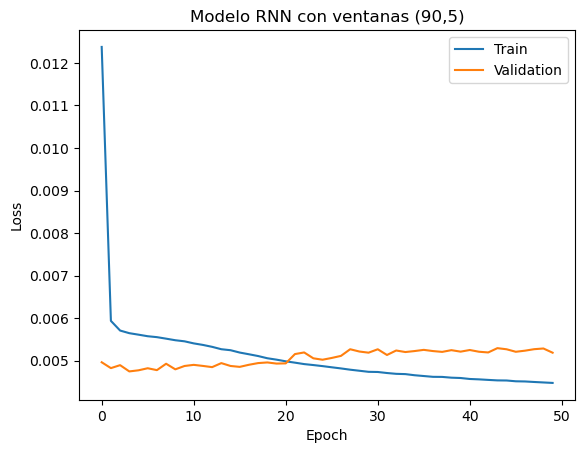

In [ ]:
plt.plot(hist_RNN_90_5.history['loss'])
plt.plot(hist_RNN_90_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (90,5)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_90_5 = model_RNN_90_5.predict(train_data_90_5)
y_pred_rnn_scaled_val_90_5 = model_RNN_90_5.predict(val_data_90_5)
y_pred_rnn_scaled_test_90_5 = model_RNN_90_5.predict(test_data_90_5 )

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_90_5 = dicc_scaler[(90,5)]
y_pred_rnn_real_train_90_5 = scaler_y_90_5.inverse_transform(y_pred_rnn_scaled_train_90_5)
y_pred_rnn_real_val_90_5 = scaler_y_90_5.inverse_transform(y_pred_rnn_scaled_val_90_5)
y_pred_rnn_real_test_90_5 = scaler_y_90_5.inverse_transform(y_pred_rnn_scaled_test_90_5 )

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_90_5 = mean_absolute_error(dicc_target_train_reg[(90,5)], y_pred_rnn_real_train_90_5)
mae_rnn_val_90_5 = mean_absolute_error(dicc_target_val[(90,5 )], y_pred_rnn_real_val_90_5)
mae_rnn_test_90_5 = mean_absolute_error(dicc_target_test[(90,5)], y_pred_rnn_real_test_90_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (90,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_90_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_90_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_90_5:.6f}")
print()

##### 3.2.4.3. Modelo con 30 datos de salida

In [ ]:
train_data_90_30, train_target_90_30 = dicc_data_train_norm[(90,30)], dicc_target_train_norm[(90,30)]
val_data_90_30, val_target_90_30 = dicc_data_val_norm[(90,30)], dicc_target_val_norm[(90,30)]
test_data_90_30, test_target_90_30 = dicc_data_test_norm[(90,30)], dicc_target_test_norm[(90,30)]

In [95]:
model_RNN_90_30 = Sequential()

model_RNN_90_30.add(LSTM(64, input_shape=(train_data_90_30.shape[1], train_data_90_30.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_90_30.add(Dropout(0.3))
#model_RNN_90_30.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_90_30.add(LSTM(32))
model_RNN_90_30.add(Dense(train_target_90_30.shape[1], activation='linear'))

model_RNN_90_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_90_30.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_52 (LSTM)                  │ (None, 90, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_53 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_90_30 = model_RNN_90_30.fit(train_data_90_30, train_target_90_30, validation_data=(val_data_90_30, val_target_90_30), epochs=300)

Epoch 1/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 60s 120ms/step - loss: 0.0102 - val_loss: 0.0023
Epoch 2/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 40s 117ms/step - loss: 0.0026 - val_loss: 0.0020
Epoch 3/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 42s 125ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 4/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 42s 123ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 5/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 43s 126ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 6/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 42s 123ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 7/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 42s 123ms/step - loss: 0.0022 - val_loss: 0.0022
Epoch 8/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 40s 119ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 9/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 39s 115ms/step - loss: 0.0021 - val_loss: 0.0022
Epoch 10/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 11/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 38s 112ms/step - loss: 0.0020 - val_loss: 0.0022
Epoch 12/50
339/339

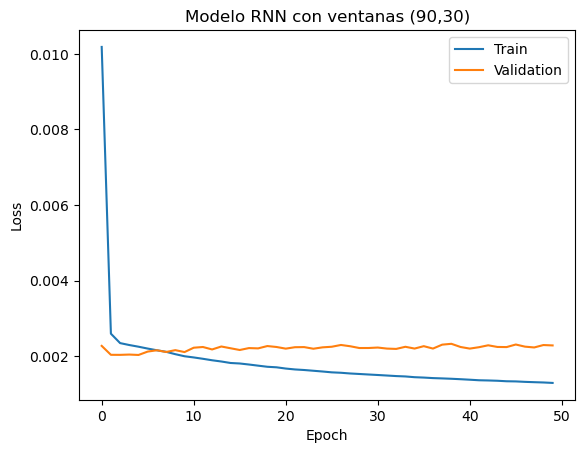

In [ ]:
plt.plot(hist_RNN_90_30.history['loss'])
plt.plot(hist_RNN_90_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (90,30)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_90_30 = model_RNN_90_30.predict(train_data_90_30)
y_pred_rnn_scaled_val_90_30 = model_RNN_90_30.predict(val_data_90_30)
y_pred_rnn_scaled_test_90_30 = model_RNN_90_30.predict(test_data_90_30)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_90_30 = dicc_scaler[(90,30)]
y_pred_rnn_real_train_90_30 = scaler_y_90_30.inverse_transform(y_pred_rnn_scaled_train_90_30)
y_pred_rnn_real_val_90_30 = scaler_y_90_30.inverse_transform(y_pred_rnn_scaled_val_90_30)
y_pred_rnn_real_test_90_30 = scaler_y_90_30.inverse_transform(y_pred_rnn_scaled_test_90_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_90_30 = mean_absolute_error(dicc_target_train_reg[(90,30)], y_pred_rnn_real_train_90_30)
mae_rnn_val_90_30 = mean_absolute_error(dicc_target_val[(90,30)], y_pred_rnn_real_val_90_30)
mae_rnn_test_90_30 = mean_absolute_error(dicc_target_test[(90,30)], y_pred_rnn_real_test_90_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (90,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_90_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_90_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_90_30:.6f}")
print()

##### 3.2.4.4. Modelo con 90 datos de salida

In [ ]:
train_data_90_90, train_target_90_90 = dicc_data_train_norm[(90,90)], dicc_target_train_norm[(90,90)]
val_data_90_90, val_target_90_90 = dicc_data_val_norm[(90,90)], dicc_target_val_norm[(90,90)]
test_data_90_90, test_target_90_90 = dicc_data_test_norm[(90,90)], dicc_target_test_norm[(90,90)]

In [99]:
model_RNN_90_90 = Sequential()

model_RNN_90_90.add(LSTM(64, input_shape=(train_data_90_90.shape[1], train_data_90_90.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_90_90.add(Dropout(0.3))
#model_RNN_90_90.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_90_90.add(LSTM(32))
model_RNN_90_90.add(Dense(train_target_90_90.shape[1], activation='linear'))

model_RNN_90_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_90_90.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_54 (LSTM)                  │ (None, 90, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_55 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_90_90 = model_RNN_90_90.fit(train_data_90_90, train_target_90_90, validation_data=(val_data_90_90, val_target_90_90), epochs=300)

Epoch 1/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 46s 114ms/step - loss: 0.0094 - val_loss: 0.0016
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 38s 112ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 108ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 5/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 6/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 8/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 9/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 10/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 11/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 12/50
338/338

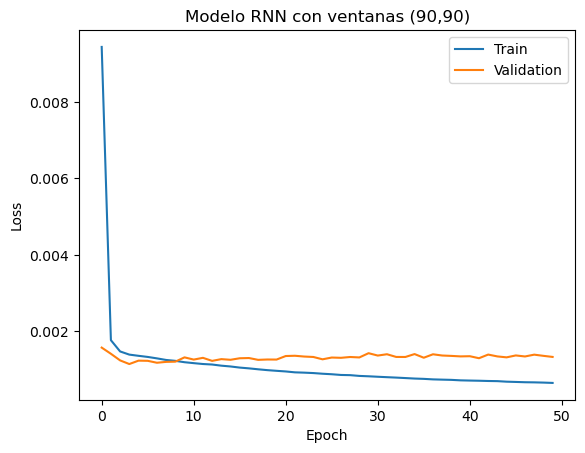

In [ ]:
plt.plot(hist_RNN_90_90.history['loss'])
plt.plot(hist_RNN_90_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo RNN con ventanas (90,90)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_rnn_scaled_train_90_90 = model_RNN_90_90.predict(train_data_90_90)
y_pred_rnn_scaled_val_90_90 = model_RNN_90_90.predict(val_data_90_90)
y_pred_rnn_scaled_test_90_90 = model_RNN_90_90.predict(test_data_90_90)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_90_90 = dicc_scaler[(90,90)]
y_pred_rnn_real_train_90_90 = scaler_y_90_90.inverse_transform(y_pred_rnn_scaled_train_90_90)
y_pred_rnn_real_val_90_90 = scaler_y_90_90.inverse_transform(y_pred_rnn_scaled_val_90_90)
y_pred_rnn_real_test_90_90 = scaler_y_90_90.inverse_transform(y_pred_rnn_scaled_test_90_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_rnn_train_90_90 = mean_absolute_error(dicc_target_train_reg[(90,90)], y_pred_rnn_real_train_90_90)
mae_rnn_val_90_90 = mean_absolute_error(dicc_target_val[(90,90)], y_pred_rnn_real_val_90_90)
mae_rnn_test_90_90 = mean_absolute_error(dicc_target_test[(90,90)], y_pred_rnn_real_test_90_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo RNN (90,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_rnn_train_90_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_rnn_val_90_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_rnn_test_90_90:.6f}")
print()